# All-Risk Exceedance Comparison

- **Summary**: This document compares exceedance curves of epidemic severity calibrated using the power law fit and the duration-sensitive power law simulation.
- **Data Required:** `data/raw/novel_resp_241228.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Feb 20, 2025

In [47]:
## Set project path
project_path = "/Users/thomasli/Desktop/epidemic-model-comp-temp"


In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import bernoulli, genpareto, lognorm
from scipy.optimize import minimize
from scipy.integrate import quad
# from scipy.optimize import root

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Set random seed
np.random.seed(42)


## 0. Prepare epidemic data

In [49]:
## Read epidemic data
df_resp = pd.read_excel(f"{project_path}/data/raw/novel_resp_241228.xlsx")

## Extract severity of COVID-19
covid_severity = df_resp.loc[df_resp['disease'] == 'covid-19', 'severity_smu'].values[0]

## Display data
df_resp


,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,pandemic spanish flu,1918,1920,3,32000.000,1873300.000,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
1,pandemic of asian flu,1957,1958,2,2000.000,2873306.000,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
2,hong kong flu,1968,1969,2,1000.000,3551599.000,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
3,hiv/aids pandemic,1981,2024,44,42300.000,4536996.619,9.323348,93.233484,hiv/aids,viral,fluid,1,0,1,1
4,global sars,2003,2003,1,0.744,6381185.141,0.000117,0.001166,sars,viral,droplet,1,0,1,1
5,swine flu,2009,2009,1,284.500,6872767.000,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
6,global mers,2012,2017,6,0.659,7125827.957,0.000092,0.000925,mers,viral,droplet,1,0,1,1
7,western africa,2013,2016,4,11.325,7210582.000,0.001571,0.015706,ebola,viral,blood/fluid,1,0,1,1
8,global covid-19,2019,2024,6,7100.000,7740000.000,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [50]:
## Define variables to estimate mortality losses
population = 7.91e9  ## global population 
vsl = 1.3e6  ## value of a statistical life ($1.3 million)
discount = 0.04  ## social discount rate


## 1. Define arrival rates

In [51]:
## Define threshold as 0.01 SMU
tau_m = 0.01

## Define arrival rate for threshold-exceeding epidemics in the past 20 years
lambda_resp_m = 3/20


In [52]:
## Define a grid of severities from 0.01 to 280 SMUs for graphs later
severity = np.logspace(np.log10(tau_m), np.log10(280), num=200).tolist()


## 2. Import exceedance from Madhav et al. (2023)

In [53]:
## Import exceedance probabilities from Table 4 of Madhav et al. (2023)
df_exceed_madhav = pd.read_excel(f"{project_path}/data/raw/madhav_exceedance.xlsx")

## 3. Calibrate power law fit

In [54]:
## Subset to major respiratory epidemics
df_resp_major = df_resp[df_resp['severity_smu'] > tau_m]

## Fit generalized Pareto distribution on major epidemics
gpd_params = genpareto.fit(df_resp_major['severity_smu'], floc = tau_m)

## Extract parameters from fit
xi = gpd_params[0]
tau_m = gpd_params[1]
sigma = gpd_params[2]

## Print parameters
print("Fitted GPD parameters for severity:")
print(f"- ξ, xi (shape) = {xi:.3f}")
print(f"- τ_m, tau_m (location/threshold) = {tau_m:.3f}")
print(f"- σ, sigma (scale) = {sigma:.3f}")
print()


Fitted GPD parameters for severity:
- ξ, xi (shape) = 2.505
- τ_m, tau_m (location/threshold) = 0.010
- σ, sigma (scale) = 1.746



In [55]:
## Calculate power law exceedance with a grid of severities
exceedance = lambda_resp_m * (1 - genpareto.cdf(severity, *gpd_params))

df_exceed_power_law = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})


In [56]:
## Estimate return time of respiratory epidemics more severe than COVID-19
covid_exceed_power_law = lambda_resp_m * (1 - genpareto.cdf(covid_severity, *gpd_params))
covid_return_time_power_law = round(1 / covid_exceed_power_law, 2)

print('Power law fit:')
print(f'Return time of epidemics more severe than COVID-19: {covid_return_time_power_law} years')
print()


Power law fit:
Return time of epidemics more severe than COVID-19: 19.2 years



In [57]:
## Estimate severity of epidemic with a return period of 1000 years
def objective(s, lambda_resp_m, *gpd_params):
    return (0.001 - lambda_resp_m * (1 - genpareto.cdf(s, *gpd_params)))  ** 2 * 1e10

## Minimize the objective function to solve for severity
result = minimize(objective, x0=200, args=(lambda_resp_m, *gpd_params), bounds=[(1e-6, 1e4)])

## Print severity with 1000-year return period
severity_1000_year = result.x[0] if result.success else None
print("Power law fit:")

if result.success:
    print(f'Severity with a 1000-year return period: {severity_1000_year:.2f} SMU')
else:
    print('Minimization failed.')
print()


Power law fit:
Severity with a 1000-year return period: 10000.00 SMU



## 4. Perform duration-sensitive power law simulation

In [58]:
## Generate intensities (SMU/year) for epidemics
df_resp['intensity_smu'] = df_resp['severity_smu'] / df_resp['duration']

## Subset to epidemics with intensity greater than 0.01 SMU
df_resp_intensity_major = df_resp[df_resp['intensity_smu'] > tau_m]

## Fit generalized Pareto distribution on intensity of major epidemics
gpd_params_intensity = genpareto.fit(df_resp_intensity_major['intensity_smu'], floc = tau_m)

## Extract parameters from fit
xi_intensity = gpd_params_intensity[0]
tau_m_intensity = gpd_params_intensity[1]
sigma_intensity = gpd_params_intensity[2]

## Print parameters
print("Fitted GPD parameters for intensity:")
print(f"- ξ, xi (shape) = {xi_intensity:.3f}")
print(f"- τ_m, tau_m (location/threshold) = {tau_m_intensity:.3f}")
print(f"- σ, sigma (scale) = {sigma_intensity:.3f}")
print()


Fitted GPD parameters for intensity:
- ξ, xi (shape) = 1.026
- τ_m, tau_m (location/threshold) = 0.010
- σ, sigma (scale) = 2.214



1.2157838526419509 0 3.832341441481946


<Figure size 1000x600 with 0 Axes>

([<matplotlib.axis.XTick at 0x177d2bd30>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

(0.0, 0.4)

(0.0, 10.0)

Text(0, 0.5, 'Log-normal PDF')

Text(0.5, 0, 'Duration (year)')

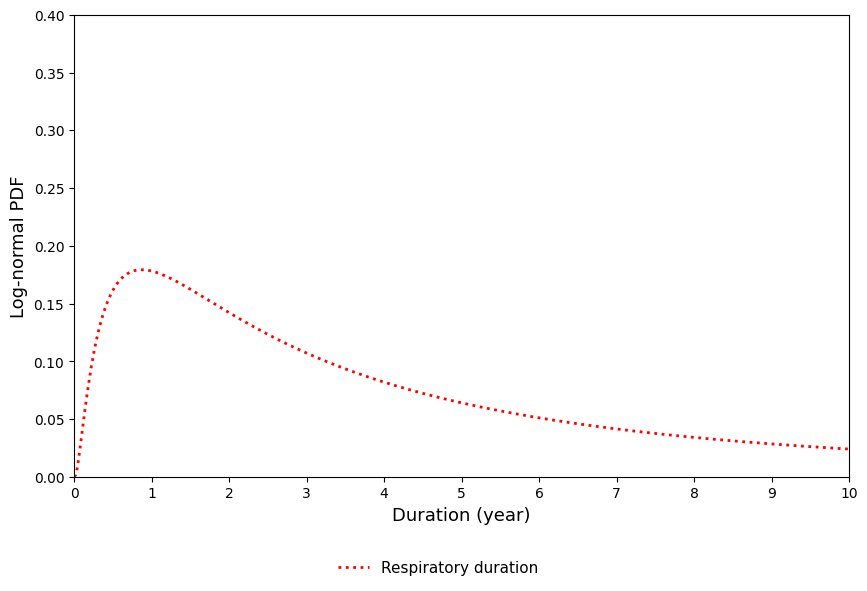

In [59]:
## Set up minimum duration truncation
duration_min = 0

## Fit log-normal distribution for all-viral durations 
shape, loc, scale = lognorm.fit(df_resp_intensity_major['duration'], floc = duration_min) 
print(shape, loc, scale)

## generate linespace for duration probability density
duration_space = np.linspace(0, 10, 500)  ## 20 years max
pdf_resp = lognorm.pdf(duration_space, s=shape,loc=loc, scale=scale)

## Plot duration densities for all-viral and respiratory
plt.figure(figsize=(10, 6))

## Plot all-viral duration density
plt.plot(duration_space, pdf_resp, 'r:', lw=2, label=f'Respiratory duration')

plt.xticks(np.arange(0, 11))
plt.ylim(0, 0.4)
plt.xlim(0, 10)

plt.ylabel('Log-normal PDF', fontsize=13)
plt.xlabel('Duration (year)', fontsize=13)

## Add legend below the plot in 'ncol' column(s) without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig(f'{project_path}/outputs/graphs/02_duration_lognorm.jpg', dpi=400, bbox_inches = 'tight')

plt.show()


In [60]:
## Set simulation parameters
num_simulations = 1e6  ## number of simulations
max_intensity = df_resp_intensity_major['intensity_smu'].max()  ## cap maximum intensity allowed
max_duration = df_resp_intensity_major['duration'].max()  ## cap maximum duration allowed

## Specify alternative maximum intensity
# max_intensity = 534/3


In [61]:
## Simulate epidemic severity with intensity and duration
def simulate_epidemic(lambda_resp_m, gpd_params_intensity, shape, loc, scale, max_intensity, max_duration):
    """
    Simulate the epidemic severity based on the given parameters.
    
    Parameters:
    - lambda_resp_m: probability of a major epidemic occurring
    - gpd_params_intensity: parameters for the GPD for intensity
    - shape, loc, scale: parameters for the log-normal distribution for duration
    - max_intensity: the maximum allowed intensity
    - max_duration: the maximum allowed duration
    
    Returns:
    - severity: the simulated epidemic severity
    """
    
    ## Step 1: Does a major epidemic occur?
    if bernoulli.rvs(lambda_resp_m, random_state=rng):

        ## Step 2: Draw intensity if major epidemic occurs
        intensity = genpareto.rvs(*gpd_params_intensity, random_state=rng)
        intensity = min(intensity, max_intensity)
        
        ## Step 3: Draw duration for epidemic
        duration = lognorm.rvs(shape, loc, scale, random_state=rng)
        duration = min(duration, max_duration)
        
        ## Step 4: Compute epidemic severity
        severity = intensity * duration
        return severity
    
    else:
        ## If no epidemic occurs, return 0 severity
        return 0
    

In [62]:
## Create random generator with fixed seed
rng = np.random.default_rng(42)

## Run simulation
severities_simulated = []
for _ in range(int(num_simulations)):
    severity_simulated = simulate_epidemic(lambda_resp_m, gpd_params_intensity, shape, loc, scale, max_intensity, max_duration)
    severities_simulated.append(severity_simulated)

## Convert the list to an array
severities_simulated = np.array(severities_simulated)

## Display basic statistics
print(f"Mean severity: {severities_simulated.mean():.2f} SMU")
print(f"Max severity: {severities_simulated.max():.2f} SMU")
print(f"Proportion of zero-severity years: {(severities_simulated == 0).mean():.2%}")
print()

## Calculate expected annual mortality loss from decomposed power law simulation
print("Decomposed power law simulation:")
print()

aal_decomposed_sim = np.mean(severities_simulated)
expected_mortality_loss = (aal_decomposed_sim / 1e4) * population * vsl / 1e12 
print(f"AAL = {aal_decomposed_sim:.2f} SMU")
print(f"Expected mortality loss = ${expected_mortality_loss:.2f} trillion")
print()


Mean severity: 8.12 SMU
Max severity: 2505.38 SMU
Proportion of zero-severity years: 85.02%

Decomposed power law simulation:

AAL = 8.12 SMU
Expected mortality loss = $8.35 trillion



In [63]:
## Create dataframe for simulated severities
df_exceed_power_law_sim = pd.DataFrame({'severity': severities_simulated})
df_exceed_power_law_sim = df_exceed_power_law_sim.sort_values(by='severity', ascending=False).reset_index(drop=True)

## Calculate exceedance probabilities
df_exceed_power_law_sim['exceedance'] = (1 + df_exceed_power_law_sim.index) / (df_exceed_power_law_sim.shape[0] + 1)

## Group by severity and calculate exceedance at each severity
df_exceed_power_law_sim = df_exceed_power_law_sim.groupby('severity', as_index=False)['exceedance'].min() 
df_exceed_power_law_sim.reset_index(drop=True, inplace=True)

## Drop row with 0 severity
df_exceed_power_law_sim = df_exceed_power_law_sim[df_exceed_power_law_sim["severity"] != 0].reset_index(drop=True)


In [64]:
## Estimate return time of respiratory epidemics more severe than COVID-19
df_exceed_power_law_sim_covid = df_exceed_power_law_sim[df_exceed_power_law_sim["severity"] > covid_severity].reset_index(drop=True)

## Extract exceedance probability of smallest simulated epidemic that is still more severe than COVID-19
covid_exceed_power_law_sim = df_exceed_power_law_sim_covid["exceedance"].iloc[0]  

## Calculate return time
covid_return_time_power_law_sim = round(1 / covid_exceed_power_law_sim, 2)

print('Decomposed power law simulation:')
print(f'Return time of epidemics more severe than COVID-19: {covid_return_time_power_law_sim} years')
print()


Decomposed power law simulation:
Return time of epidemics more severe than COVID-19: 13.69 years



In [65]:
## Estimate severity of epidemic with a return period of 1000 years
df_exceed_power_law_sim_thousand_yr = df_exceed_power_law_sim[df_exceed_power_law_sim["exceedance"] < 0.001].reset_index(drop=True)

## Extract severity that has an exceedance closest to 0.001
severity_1000_year = df_exceed_power_law_sim_thousand_yr["severity"].iloc[0]  

print("Decomposed power law simulation:")
print(f'Severity with a 1000-year return period: {severity_1000_year:.2f} SMU')
print()


Decomposed power law simulation:
Severity with a 1000-year return period: 1014.45 SMU



## 5. Perform exceedance comparison

In [66]:
## Set label size
label_size = 13


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Severity (SMU)')

Text(0, 0.5, 'Exceedance probability')

(0.0, 280.0)

(1e-05, 1)

([<matplotlib.axis.XTick at 0x177d92070>,
 [Text(0, 0, '0'),
  Text(50, 0, '50'),
  Text(100, 0, '100'),
  Text(150, 0, '150'),
  Text(200, 0, '200'),
  Text(250, 0, '250'),
  Text(280, 0, '280')])

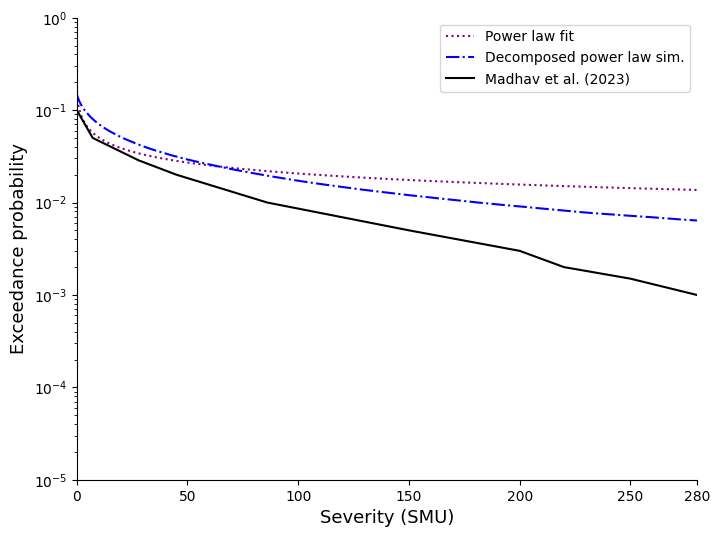

In [67]:
## Plot exceedance curve comparison
plt.figure(figsize=(8, 6))
# plt.plot(df_exceed_hyperbolic["severity"], df_exceed_hyperbolic["exceedance"], label="Hyperbolic fit", linestyle="--", color="green")
plt.plot(df_exceed_power_law["severity"], df_exceed_power_law["exceedance"], label="Power law fit", linestyle=":", color="purple")
plt.plot(df_exceed_power_law_sim["severity"], df_exceed_power_law_sim["exceedance"], label="Decomposed power law sim.", linestyle="-.", color="blue") 
plt.plot(df_exceed_madhav["severity"], df_exceed_madhav["exceedance"], label="Madhav et al. (2023)", linestyle="-", color="black")

## Add labels and legend
plt.xlabel("Severity (SMU)", fontsize=label_size)
plt.ylabel("Exceedance probability", fontsize=label_size)
plt.yscale("log")  ## log scale
plt.xlim(0, 280)  ## x-axis limit
plt.ylim(1e-5, 1)  ## y-axis limit
plt.xticks([0, 50, 100, 150, 200, 250, 280])

plt.gca().spines['top'].set_visible(False)  
plt.gca().spines['right'].set_visible(False)  
# plt.legend(frameon=False)
plt.legend()

## Save graph as jpg file at 400 dpi
plt.savefig(f'{project_path}/outputs/graphs/02_exceed_comp.jpg', dpi=400, bbox_inches = 'tight')

# Show plot
plt.show()

## 6. Calculate AAL under different maximum severities

In [68]:
## Set maximum severities using possible 1918 flu severity
severity_max = [80, 171, 534, 10000]


In [69]:
## Calculate AAL under power law fit

## Compute truncated expected AAL under power law fit
def expected_severity_power_law(s_max, lambda_resp_m, *gpd_params):
    loc = gpd_params[1] 
    integral, _ = quad(lambda s: s * genpareto.pdf(s, *gpd_params), loc, s_max)
    exceedance = 1 - genpareto.cdf(s_max, *gpd_params)
    return lambda_resp_m * (integral + exceedance * s_max)

print("Power law fit (all-risk):")
print()

for s_max in severity_max:
    aal_power_law = expected_severity_power_law(s_max, lambda_resp_m, *gpd_params)
    expected_mortality_loss = (aal_power_law / 1e4) * population * vsl / 1e12  ## convert to trillion dollars
    print(f"Max severity = {s_max} SMU")
    print(f"AAL = {aal_power_law:.2f} SMU")
    print(f"Expected mortality loss = ${expected_mortality_loss:.2f} trillion")
    print()


Power law fit (all-risk):

Max severity = 80 SMU
AAL = 2.85 SMU
Expected mortality loss = $2.93 trillion

Max severity = 171 SMU
AAL = 4.58 SMU
Expected mortality loss = $4.71 trillion

Max severity = 534 SMU
AAL = 9.24 SMU
Expected mortality loss = $9.50 trillion

Max severity = 10000 SMU
AAL = 54.52 SMU
Expected mortality loss = $56.06 trillion



In [70]:
## Calculate expected annual mortality loss from Madhav et al.
aal_compartmental = 3.2

expected_mortality_loss = (aal_compartmental / 1e4) * population * vsl / 1e12 
print("Compartmental simulation (respiratory only):")
print()

print(f"AAL = {aal_compartmental} SMU")
print(f"Expected mortality loss = ${expected_mortality_loss:.2f} trillion")
print()


Compartmental simulation (respiratory only):

AAL = 3.2 SMU
Expected mortality loss = $3.29 trillion

